In [1]:
from langchain_openai import ChatOpenAI
import os
#from langchain_google_genai import ChatGoogleGenerativeAI

base_url= os.getenv("AICREDITS_BASE_URL")
api_key = os.getenv("AICREDITS_API_KEY")

llm = ChatOpenAI(
    model="google/gemini-2.0-flash",
    api_key=api_key,
    base_url=base_url,
    #temperature=1.0
)

# Test the model
response = llm.invoke("Hello!")
print(response.content)


Hello! How can I help you today?


# Plan and Solve Agent

In [2]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
class Plan(BaseModel):
    """Plan to follow in future"""

    steps: list[str] = Field(
        description="different steps to follow, should be in sorted order"
    )


system_prompt_template = (
    "For the given task, come up with a step by step plan.\n"
    "This plan should involve individual tasks, that if executed correctly will "
    "yield the correct answer. Do not add any superfluous steps.\n"
    "The result of the final step should be the final answer. Make sure that each "
    "step has all the information needed - do not skip steps."
)
planner_prompt = ChatPromptTemplate.from_messages(
    [("system", system_prompt_template),
     ("user", "Prepare a plan how to solve the following task:\n{task}\n")])

planner = planner_prompt | llm.with_structured_output(Plan)

Defining the calculator tool

In [3]:
from pydantic import BaseModel, Field
from langchain_core.runnables import RunnableLambda, RunnableConfig
from langchain_core.tools import tool, convert_runnable_to_tool
import numexpr as ne


class CalculatorArgs(BaseModel):
    expression: str = Field(description="Mathematical expression to be evaluated")

def calculator(state: CalculatorArgs, config: RunnableConfig) -> str:
    expression = state["expression"]
    math_constants = config["configurable"].get("math_constants", {})
    result = ne.evaluate(expression.strip(), local_dict=math_constants)
    return str(result)


calculator_with_retry = RunnableLambda(calculator).with_retry(
    wait_exponential_jitter=True,
    stop_after_attempt=3,
)

calculator_tool = convert_runnable_to_tool(
    calculator_with_retry,
    name="calculator",
    description=(
        "Calculates a single mathematical expression, incl. complex numbers."
        "'\nAlways add * to operations, examples:\n73i -> 73*i\n"
        "7pi**2 -> 7*pi**2"
    ),
    args_schema=CalculatorArgs,
    arg_types={"expression": "str"},
)

In [4]:
from langchain_community.agent_toolkits.load_tools import load_tools

llm2 = ChatOpenAI(
    model="google/gemini-2.0-flash",
    api_key=api_key,
    base_url=base_url)

tools = load_tools(
  tool_names=["ddg-search", "arxiv", "wikipedia"],
  llm=llm2
)

C:\Users\Shivachetan Ulavi\AppData\Local\Temp\ipykernel_15892\1674759377.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.agent_toolkits.load_tools import load_tools


Using these tools with the ReACT agent

In [5]:
from langgraph.prebuilt import create_react_agent
from langgraph.prebuilt.chat_agent_executor import AgentState


system_prompt = (
    "You're a smart assistant that carefully helps to solve complex tasks.\n"
    " Given a general plan to solve a task and a specific step, work on this step. "
    " Don't assume anything, keep in minds things might change and always try to "
    "use tools to double-check yourself.\m"
    " Use a calculator for mathematical computations, use Search to gather"
    "for information about common facts, fresh events and news, use Arxiv to get "
    "ideas on recent research and use Wikipedia for common knowledge."
)

step_template = (
    "Given the task and the plan, try to execute on a specific step of the plan.\n"
    "TASK:\n{task}\n\nPLAN:\n{plan}\n\nSTEP TO EXECUTE:\n{step}\n"
)

prompt_template = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("user", step_template),
])

class StepState(AgentState):
  plan: str
  step: str
  task: str

execution_agent = create_react_agent(model=llm2, tools=tools+[calculator_tool], state_schema=StepState, prompt=prompt_template)

C:\Users\Shivachetan Ulavi\AppData\Local\Temp\ipykernel_15892\3410082584.py:30: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  execution_agent = create_react_agent(model=llm2, tools=tools+[calculator_tool], state_schema=StepState, prompt=prompt_template)


Defining the Agent State

In [6]:
from typing import Annotated, TypedDict
import operator


task = "Write a strategic one-pager of building an AI startup in Bangalore?"

In [7]:
class PlanState(TypedDict):
    task: str
    plan: Plan
    past_steps: Annotated[list[str], operator.add]
    final_response: str


def get_current_step(state: PlanState) -> int:
  """Returns the number of current step to be executed."""
  return len(state.get("past_steps", []))

def get_full_plan(state: PlanState) -> str:
  """Returns formatted plan with step numbers and past results."""
  full_plan = []
  for i, step in enumerate(state["plan"].steps):
    full_step = f"# {i+1}. Planned step: {step}\n"
    if i < get_current_step(state):
      full_step += f"Result: {state['past_steps'][i]}\n"
    full_plan.append(full_step)
  return "\n".join(full_plan)

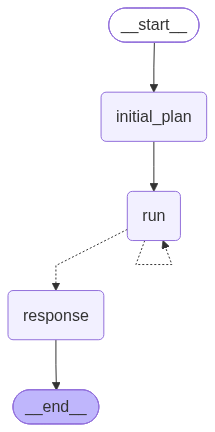

In [9]:
from typing import Literal
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph, START, END


final_prompt = PromptTemplate.from_template(
    "You're a helpful assistant that has executed on a plan."
    "Given the results of the execution, prepare the final response.\n"
    "Don't assume anything\nTASK:\n{task}\n\nPLAN WITH RESUlTS:\n{plan}\n"
    "FINAL RESPONSE:\n"
)

async def _build_initial_plan(state: PlanState) -> PlanState:
  plan = await planner.ainvoke(state["task"])
  return {"plan": plan}

async def _run_step(state: PlanState) -> PlanState:
  plan = state["plan"]
  current_step = get_current_step(state)
  step = await execution_agent.ainvoke({"plan": get_full_plan(state), "step": plan.steps[current_step], "task": state["task"]})
  return {"past_steps": [step["messages"][-1].content]}

async def _get_final_response(state: PlanState) -> PlanState:
  final_response = await (final_prompt | llm2).ainvoke({"task": state["task"], "plan": get_full_plan(state)})
  return {"final_response": final_response}


def _should_continue(state: PlanState) -> Literal["run", "response"]:
  if get_current_step(state) < len(state["plan"].steps):
    return "run"
  return "response"

builder = StateGraph(PlanState)
builder.add_node("initial_plan", _build_initial_plan)
builder.add_node("run", _run_step)
builder.add_node("response", _get_final_response)

builder.add_edge(START, "initial_plan")
builder.add_edge("initial_plan", "run")
builder.add_conditional_edges("run", _should_continue)
builder.add_edge("response", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
task = "Write a strategic one-pager of building an AI startup"
result = await graph.ainvoke({"task": task})

In [11]:
print(result["final_response"].content)

# MindMend AI: Revolutionizing Adolescent Mental Health with Empathetic AI

## Executive Summary & Vision

MindMend AI is an innovative AI-powered platform dedicated to providing personalized, proactive, and destigmatized mental health support for adolescents (13-18). Our long-term vision is to be the global leader in youth mental well-being, fundamentally shifting the paradigm from reactive crisis management to proactive emotional resilience cultivation. By leveraging advanced AI, we aim to offer immediately accessible, clinically sound, and engaging support, empowering young people to thrive while reducing the significant barriers and stigma associated with traditional mental healthcare.

## 1. Core Problem Statement

Adolescents face escalating mental health challenges (anxiety, depression, stress) exacerbated by social pressures and digital overload. Existing mental healthcare systems are overwhelmed, under-resourced, and stigmatized, creating significant access barriers to timely,

In [12]:
async for output in graph.astream({"task": task}, stream_mode="updates"):
    for key, value in output.items():
        print(f"Output from node '{key}':")
        print("---")
        print(value)
    print("\n---\n")

Output from node 'initial_plan':
---
{'plan': Plan(steps=["Define the AI startup's core problem statement, target audience, and unique value proposition.", 'Outline the specific AI technology or approach to be used and its differentiation from competitors.', 'Detail the product or service offering, including key features and benefits.', 'Develop a high-level business model, including revenue streams and pricing strategy.', 'Identify the go-to-market strategy, including initial customer acquisition and sales channels.', "Summarize the team's key strengths and relevant experience.", 'Specify key financial projections, including funding needs and expected milestones.', 'Articulate the long-term vision and potential impact of the AI startup.'])}

---

Output from node 'run':
---
{'past_steps': ['The core problem statement, target audience, and unique value proposition are defined as follows:\n\n**Core Problem Statement:** Many small to medium-sized businesses (SMBs) lack the resources and 